# 04_02 - Feature Importance: Regressor vs. Classifier

Both models share the same 18 `SELECTED_FEATURES`, chosen and validated once in `02_01_feature_engineering.ipynb` against the Regressor's target (`log_consumption`), then reused as-is for the Classifier's target (`actual_peak`). This notebook checks whether the two models, once actually trained, lean on those 18 features the same way. Gain-based importance is extracted from the real, final Regressor and Classifier, both trained on fold_3 (train 2021-2024, the most recent and largest training window), and compared side by side.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parents[1] / "src"))

import pandas as pd
import matplotlib.pyplot as plt
from common.folds import split_fold
from common.labeling import compute_peak_thresholds, label_peaks
from common.transforms import set_categorical_dtypes
from common.feature_selection import SELECTED_FEATURES, gain_importance
from forecast.XGBoost_Regressor import build_training_table as build_regressor_table, make_model as make_regressor, LOG_TARGET_COLUMNS
from peak_risk.XGBoost_Classifier import build_training_table as build_classifier_table, make_model as make_classifier, CLASSIFIER_FEATURES

DATA_PATH = Path.cwd().parents[1] / "data" / "interim" / "fsa_hourly_master.parquet"
df = pd.read_parquet(DATA_PATH)

## 1. Regressor importance

The Regressor is trained on fold_3's train years exactly as in `02_04_xgboost_regressor_training.ipynb`, then `gain_importance()` reads off `feature_importances_` from the fitted model.

In [2]:
regressor_table = build_regressor_table(df)
regressor_train, _ = split_fold(regressor_table, "fold_3")

regressor_model = make_regressor()
regressor_model.fit(regressor_train[SELECTED_FEATURES], regressor_train[LOG_TARGET_COLUMNS])

regressor_importance = gain_importance(regressor_model, SELECTED_FEATURES)
regressor_importance.to_frame("gain")

,gain
FSA,0.745918
hour,0.051612
Visibility (km),0.045200
season,0.025111
is_business_hour,0.020066
Temp (°C),0.018798
is_peak_hour_window,0.017190
year,0.016126
PREMISE_COUNT,0.015924
Precip. Amount (mm),0.010967


## 2. Classifier importance

Same idea, trained on fold_3 exactly as in `03_01_xgboost_classifier_training.ipynb`: thresholds from that fold's own raw training hours, labels applied, `scale_pos_weight` computed from the labeled train split, then `gain_importance()` on `CLASSIFIER_FEATURES` (the same 18, plus `horizon`).

In [3]:
classifier_table = build_classifier_table(df)
raw_train, _ = split_fold(df, "fold_3")
classifier_train, _ = split_fold(classifier_table, "fold_3")

thresholds = compute_peak_thresholds(raw_train)
classifier_train_labeled = label_peaks(classifier_train, thresholds, value_col="actual", season_col="forecast_season")
classifier_train_labeled = set_categorical_dtypes(classifier_train_labeled)

n_pos = (classifier_train_labeled["actual_peak"] == 1).sum()
n_neg = (classifier_train_labeled["actual_peak"] == 0).sum()
classifier_model = make_classifier(scale_pos_weight=n_neg / n_pos)
classifier_model.fit(classifier_train_labeled[CLASSIFIER_FEATURES], classifier_train_labeled["actual_peak"])

classifier_importance = gain_importance(classifier_model, CLASSIFIER_FEATURES)
classifier_importance.to_frame("gain")

,gain
Temp (°C),0.132194
season,0.103538
Dew Point Temp (°C),0.079194
hour,0.076321
is_daylight_saving_time,0.070917
horizon,0.062794
is_business_hour,0.061651
FSA,0.060580
month_cos,0.057098
Precip. Amount (mm),0.044253


## 3. Side by side

`horizon` only exists for the Classifier, it gets a blank Regressor rank rather than being dropped from the table.

In [4]:
comparison = pd.DataFrame({
    "regressor_gain": regressor_importance,
    "classifier_gain": classifier_importance,
}).round(4)
comparison["regressor_rank"] = comparison["regressor_gain"].rank(ascending=False, method="min")
comparison["classifier_rank"] = comparison["classifier_gain"].rank(ascending=False, method="min")
comparison.sort_values("classifier_gain", ascending=False)

,regressor_gain,classifier_gain,regressor_rank,classifier_rank
Temp (°C),0.0188,0.1322,6.0,1.0
season,0.0251,0.1035,4.0,2.0
Dew Point Temp (°C),0.0059,0.0792,13.0,3.0
hour,0.0516,0.0763,2.0,4.0
is_daylight_saving_time,0.0077,0.0709,11.0,5.0
horizon,NaN,0.0628,NaN,6.0
is_business_hour,0.0201,0.0617,5.0,7.0
FSA,0.7459,0.0606,1.0,8.0
month_cos,0.0077,0.0571,11.0,9.0
Precip. Amount (mm),0.0110,0.0443,10.0,10.0


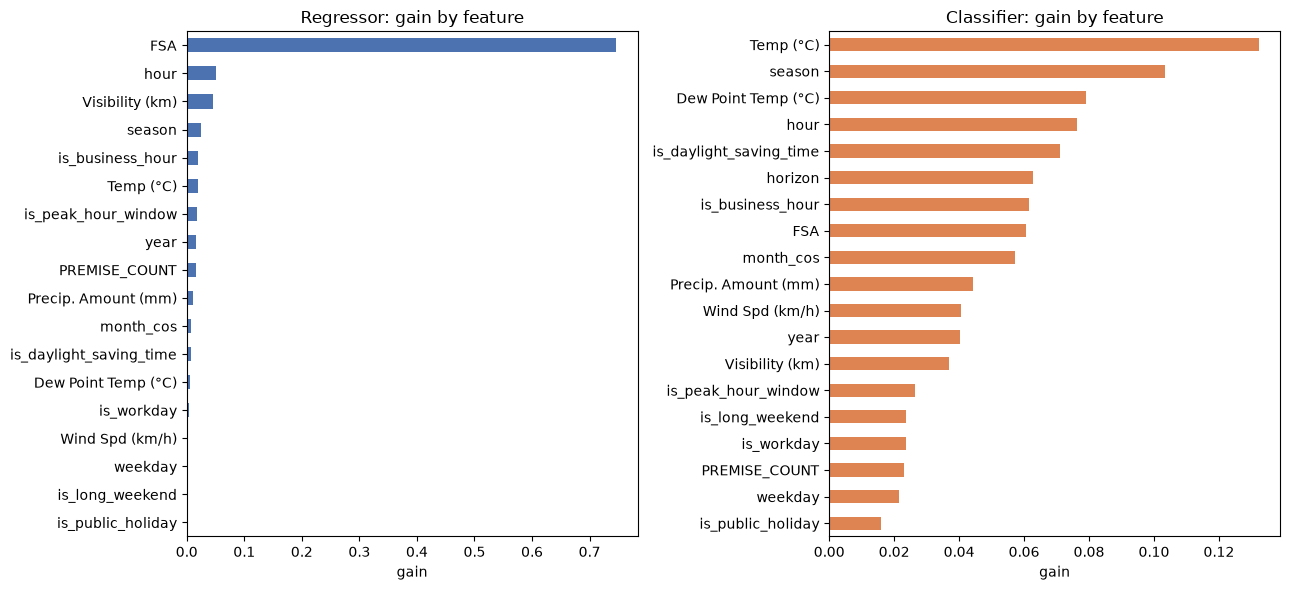

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

regressor_importance.sort_values().plot.barh(ax=axes[0], color="#4C72B0")
axes[0].set_title("Regressor: gain by feature")
axes[0].set_xlabel("gain")

classifier_importance.sort_values().plot.barh(ax=axes[1], color="#DD8452")
axes[1].set_title("Classifier: gain by feature")
axes[1].set_xlabel("gain")

fig.tight_layout()
plt.show()

The two rankings barely resemble each other. `FSA` takes 0.746 of all gain in the Regressor, by far the single largest share of any feature in either model, then drops to rank 8 (0.061) in the Classifier. `Temp (°C)`, `season`, and `Dew Point Temp (°C)` take the opposite path: all three sit in the bottom half of the Regressor's ranking (ranks 6, 4, and 13) but climb to the top 3 in the Classifier.

Both directions make sense given what each target actually is. `TOTAL_CONSUMPTION` differs enormously in scale between FSAs (M5S averages around 4,100 kWh, M9W around 12,300), so a regressor predicting the raw value leans hard on `FSA` just to get the right order of magnitude before anything else matters. `actual_peak`, by contrast, is already defined relative to each FSA's own distribution, the threshold is the 97.5th percentile *per FSA and season*, so the FSA-specific scale is baked into the label itself before the model ever sees a row. What is left for the classifier to explain is which hours, within an FSA's own normal range, cross into its own extreme, and that turns out to be driven far more by weather than by which FSA it is. This also lines up with the case study built for the dashboard, a heat-driven demand day where 14 of 24 hours were flagged as peaks.

`horizon` lands at rank 6 for the Classifier (0.063), meaningfully used, consistent with the earlier finding that ranking quality (PR-AUC) erodes with horizon while the Regressor's structural analogue, predicting all 24 horizons as separate output columns, has no single feature to compare it to.

## 4. What this does not answer

Gain only describes how a model split on the features it was given, it says nothing about whether a different set of features would have scored better. `SELECTED_FEATURES` was chosen and validated once, against the Regressor's target, in `02_01_feature_engineering.ipynb`. Features dropped there because they did not help predict `log_consumption` (for example `Rel Hum (%)`, `Wind Dir (10s deg)`, the `month`/`quarter`/`week_of_year`/`day_of_year` cluster) were never separately checked against `actual_peak`, and it is entirely possible one of them would help the Classifier even though it did not help the Regressor. Confirming that would need repeating the same correlation, gain, and held-out validation process from that notebook with `actual_peak` as the target, a separate piece of work, not something this notebook resolves.